Dataset Loaded Successfully
Shape: (1000000, 30)
Detected Target Column: Is_Fraudulent
Feature Shape: (1000000, 29)
Target Distribution:
 Is_Fraudulent
False    500000
True     500000
Name: count, dtype: int64
Training Logistic Regression...
Training Decision Tree...
Training KNN...

Results Table:
                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression    1.0000   1.000000  1.000000  1.000000
1        Decision Tree    1.0000   1.000000  1.000000  1.000000
2                  KNN    0.6761   0.696248  0.625766  0.659128


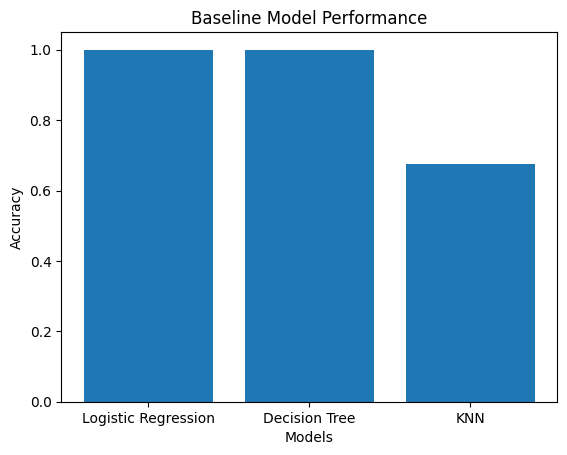


✅ RQ1 Completed Successfully


In [2]:
# ================================
# RQ1: Baseline Models (FINAL)
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
df = pd.read_csv('/kaggle/input/datasets/mahfuz95/synthetic-health-insurance-claims-fraud-detection/Synthetic_health_insurance_claims_fraud_detection.csv')

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

# -------------------------------
# Step 2: Handle Missing Values
# -------------------------------
df = df.dropna()

# -------------------------------
# Step 3: Detect Target Column
# -------------------------------
target_col = None

for col in df.columns:
    if 'fraud' in col.lower():
        target_col = col
        break

print("Detected Target Column:", target_col)

if target_col is None:
    raise Exception("No fraud column found. Check dataset manually.")

# -------------------------------
# Step 4: Encode Categorical Data
# -------------------------------
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    if col != target_col:
        df[col] = le.fit_transform(df[col].astype(str))

# Encode target if needed
if df[target_col].dtype == 'object':
    df[target_col] = le.fit_transform(df[target_col])

# -------------------------------
# Step 5: Define X and y
# -------------------------------
y = df[target_col]
X = df.drop(columns=[target_col])

print("Feature Shape:", X.shape)
print("Target Distribution:\n", y.value_counts())

# -------------------------------
# Step 6: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 7: Train Baseline Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

# -------------------------------
# Step 8: Create Results Table
# -------------------------------
df_results = pd.DataFrame(
    results,
    columns=['Model','Accuracy','Precision','Recall','F1']
)

print("\nResults Table:")
print(df_results)

# Save table
df_results.to_csv('RQ1_table.csv', index=False)

# -------------------------------
# Step 9: Plot Figure
# -------------------------------
plt.figure()
plt.bar(df_results['Model'], df_results['Accuracy'])

plt.title('Baseline Model Performance')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.savefig('RQ1_figure.pdf')
plt.show()

print("\n✅ RQ1 Completed Successfully")